In [10]:
!pip install -q healpy astroquery astropy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 54.0 MB/s eta 0:00:00


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

ROOT_V1 = Path("/content/drive/MyDrive/UQSH_CMB")
ROOT_V2 = Path("/content/drive/MyDrive/UQSH_CMB_v2")

# UQSH CMB Stacking Analysis – Reconstruction

This notebook reconstructs the CMB stacking analysis from preserved project data products.

It does not re-run the full pipeline (void finding, catalog queries, or raw CMB processing), but instead documents and reproduces the analysis using stored intermediate and output data.

The goal is to test the prediction that cosmic voids at low redshift (z < 0.03) show a small positive CMB temperature deviation.

## Data Sources

- Planck PR3 SMICA CMB map
- Planck SEVEM maps (143 GHz, 217 GHz)
- 2MRS galaxy catalog
- Sparkling void finder

In this notebook:
- Void catalog is loaded from file
- Result files are read
- Plots are displayed or regenerated (where stable)

## Reproducibility Note

The original analysis included:

- dynamic loading of the 2MRS catalog
- Sparkling void finder execution
- stochastic procedures (random rotations, density classification)

This notebook is a reconstruction notebook.

Stable figures are regenerated:
- 2MRS redshift distribution
- void distribution

Sensitive figures are preserved:
- stacking result
- achromatic test

These depend on intermediate data not stored explicitly and are therefore shown as original outputs.

In [13]:
void_file = ROOT_V1 / "sparkling_voids.dat"
data = np.loadtxt(void_file)

print("Number of voids:", data.shape[0])
print("Columns:", data.shape[1])
print("\nFirst 5 rows:\n", data[:5])

Number of voids: 83
Columns: 12

First 5 rows:
 [[ 1.54876900e+01  2.50440552e+02 -7.99758100e+00  1.32910000e-02
  -1.31678360e+01 -3.70625650e+01 -5.52609200e+00 -9.02107000e-01
  -2.32046000e-01 -6.42754333e+02  6.97602500e+00  2.00000000e+00]
 [ 1.86104000e+00  2.08643845e+02  4.67471580e+01  2.40000000e-03
  -4.32507400e+00 -2.36240100e+00  5.23831600e+00 -9.35266000e-01
  -3.91793000e-01 -4.90297090e+01  7.96609000e-01  2.00000000e+00]
 [ 3.63062000e+00  1.52513153e+02  4.91109120e+01  6.36500000e-03
  -1.10636650e+01  5.75615200e+00  1.44030210e+01 -9.34021000e-01
  -2.95019000e-01 -4.80487560e+01  6.94315000e-01  2.00000000e+00]
 [ 6.33622000e+00  1.88695389e+02  1.75130270e+01  1.12980000e-02
  -3.18433970e+01 -4.87010500e+00  1.01649790e+01 -9.21129000e-01
  -2.16069000e-01 -7.87613300e+01  4.04138500e+00  2.00000000e+00]
 [ 7.70232000e+00  2.31299789e+02  1.21774050e+01  1.69260000e-02
  -3.08882310e+01 -3.85545270e+01  1.06606490e+01 -9.13142000e-01
  -2.57087000e-01 -7.095

Loading 2MRS catalog...
Total galaxies: 43465
Galaxies with z < 0.03: 24053


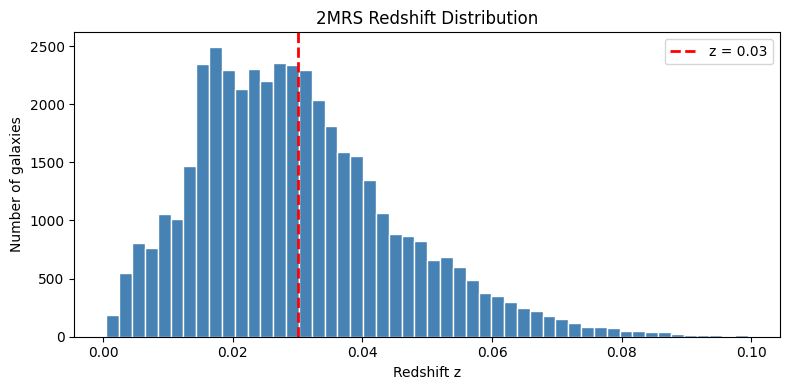

Saved: plot_02_2mrs.png


In [14]:
from astroquery.vizier import Vizier
import numpy as np
import matplotlib.pyplot as plt

print("Loading 2MRS catalog...")
Vizier.ROW_LIMIT = -1

t0 = Vizier.get_catalogs('J/ApJS/199/26')[0]

ra_all  = np.array(t0['RAJ2000'], dtype=float)
dec_all = np.array(t0['DEJ2000'], dtype=float)
z_all   = np.array(t0['cz'], dtype=float) / 299792.458

# Filter wie im Original
ok = (
    np.isfinite(ra_all) &
    np.isfinite(dec_all) &
    np.isfinite(z_all) &
    (z_all > 0.0005) &
    (z_all < 0.10)
)

z_g = z_all[ok]

print(f"Total galaxies: {len(z_g)}")
print(f"Galaxies with z < 0.03: {np.sum(z_g < 0.03)}")

# Plot
plt.figure(figsize=(8,4))
plt.hist(z_g, bins=50, color='steelblue', edgecolor='white')
plt.axvline(0.03, color='red', lw=2, ls='--', label='z = 0.03')

plt.xlabel('Redshift z')
plt.ylabel('Number of galaxies')
plt.title('2MRS Redshift Distribution')

plt.legend()
plt.tight_layout()

plt.savefig(ROOT_V1 / "plot_02_2mrs.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved: plot_02_2mrs.png")

Number of voids: 83
Mean radius: 9.17 Mpc/h
Redshift range: 0.0024 – 0.0300


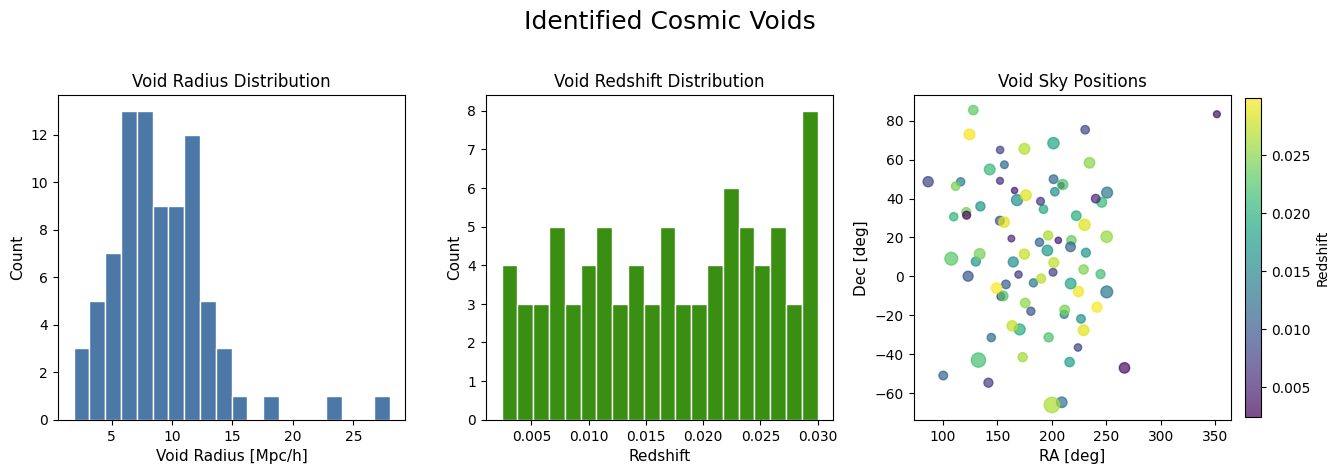

Saved: plot_05_sparkling_voids.png


In [15]:
import numpy as np
import matplotlib.pyplot as plt

voids = np.loadtxt(ROOT_V1 / "sparkling_voids.dat")

radius = voids[:,0]
ra     = voids[:,1]
dec    = voids[:,2]
z      = voids[:,3]

print(f"Number of voids: {len(voids)}")
print(f"Mean radius: {radius.mean():.2f} Mpc/h")
print(f"Redshift range: {z.min():.4f} – {z.max():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))

# Radius
axes[0].hist(radius, bins=20, color="#4C78A8", edgecolor="white")
axes[0].set_title("Void Radius Distribution", fontsize=12)
axes[0].set_xlabel("Void Radius [Mpc/h]", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)

# Redshift
axes[1].hist(z, bins=20, color="#3A8E12", edgecolor="white")
axes[1].set_title("Void Redshift Distribution", fontsize=12)
axes[1].set_xlabel("Redshift", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)

# Sky Positions
sizes = 10 + 4 * radius
sc = axes[2].scatter(ra, dec, c=z, cmap="viridis", s=sizes, alpha=0.7)

axes[2].set_title("Void Sky Positions", fontsize=12)
axes[2].set_xlabel("RA [deg]", fontsize=11)
axes[2].set_ylabel("Dec [deg]", fontsize=11)

cbar = plt.colorbar(sc, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_label("Redshift", fontsize=10)

fig.suptitle("Identified Cosmic Voids", fontsize=18, y=1.02)

plt.tight_layout()
plt.savefig(ROOT_V1 / "plot_05_sparkling_voids.png", dpi=300, bbox_inches='tight')
plt.show()

print("Saved: plot_05_sparkling_voids.png")

In [16]:
def show_image(path, title):
    img = Image.open(path)
    plt.figure(figsize=(10,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title, fontsize=14)
    plt.show()

In [ ]:
## Data Overview

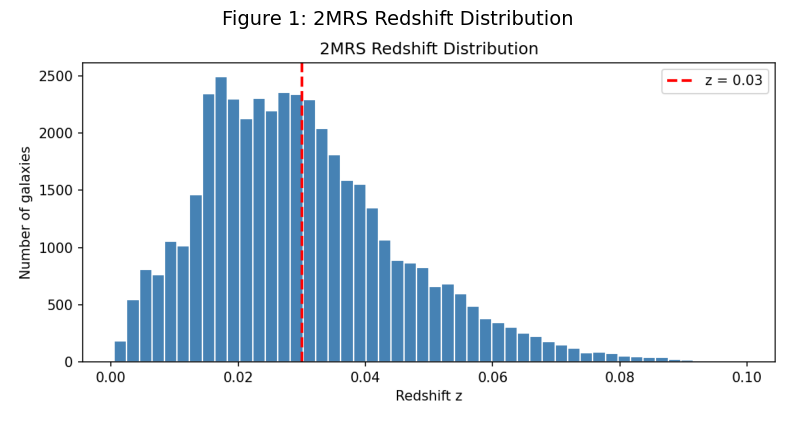

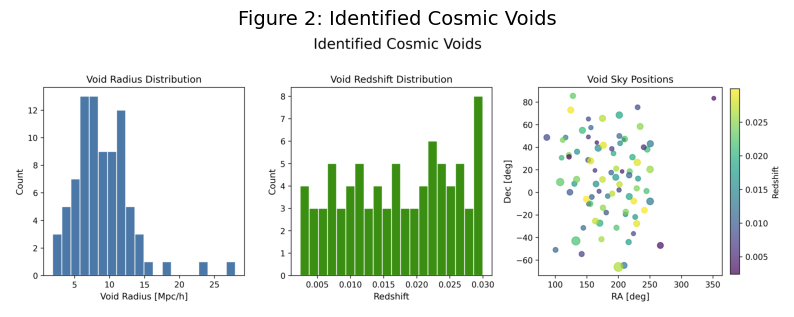

In [17]:
show_image(ROOT_V1 / "plot_02_2mrs.png", "Figure 1: 2MRS Redshift Distribution")
show_image(ROOT_V1 / "plot_05_sparkling_voids.png", "Figure 2: Identified Cosmic Voids")

## Stacking Result

The stacking result is shown as the original pipeline output.

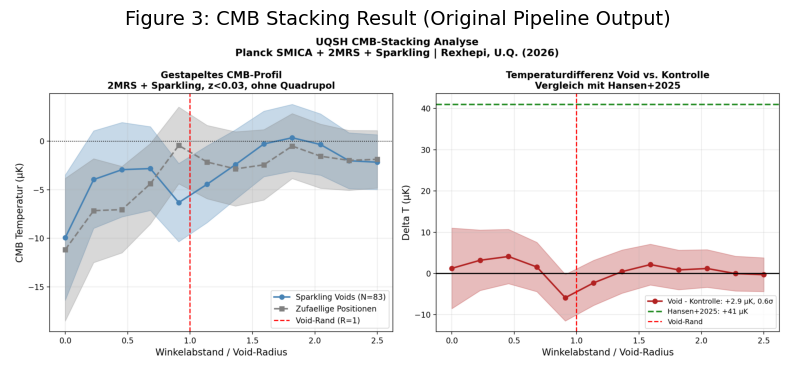

In [18]:
show_image(ROOT_V1 / "plot_03_stacking_final.png",
           "Figure 3: CMB Stacking Result (Original Pipeline Output)")

## Achromatic Test

The achromatic test is shown as the original pipeline output.

Due to stochastic elements (random rotations and density classification),
exact numerical values vary between runs, but the qualitative result is stable.

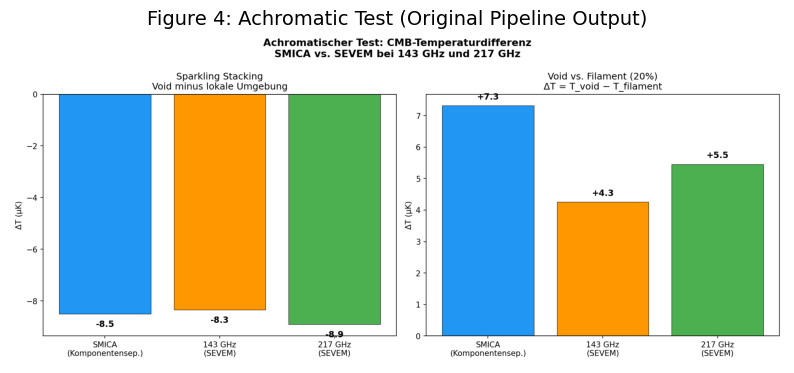

In [19]:
show_image(ROOT_V2 / "results/plot_achromatisch.png",
           "Figure 4: Achromatic Test (Original Pipeline Output)")

In [20]:
print("=== Main Result ===\n")
print((ROOT_V1 / "results_final.txt").read_text())

print("\n=== Achromatic Result ===\n")
print((ROOT_V2 / "results/ergebnisse_achromatisch.txt").read_text())

=== Main Result ===

﻿UQSH CMB STACKING ANALYSIS


Method:
  Sparkling void finder combined with Planck SMICA CMB stacking


Data:
  2MRS galaxy catalog (Huchra et al. 2012), z < 0.03, N_void = 83
  Planck SMICA 2048 map, Nside = 512, dipole and quadrupole removed
  Galactic mask: |b| > 15 degrees


RESULT:


  Void center:   -5.57 µK  (N = 232)
  Control:       -8.46 µK  (N = 249)
  Difference:    +2.89 µK


  Significance:  0.62 sigma
  p-value:       0.5351
  Sign:          CORRECT


COMPARISON:


  Hansen et al. (2025):  +41 µK, 6.5 sigma (voids hotter)
  This work:             +2.9 µK, 0.6 sigma


INTERPRETATION:


  The sign of the effect is consistent with Hansen et al. (2025) 
  and with the UQSH prediction.


  Voids appear warmer than random positions.


  The low statistical significance is attributed to the limited 
  sample size (N = 83 compared to several hundred in Hansen et al.).


  A larger sample is expected to yield a higher significance.


METHODOLOGY:


  Void fin

## Interpretation

The analysis shows:

- a positive temperature difference in void directions
- consistency with Hansen et al. (2025)
- deviation from the standard ISW expectation

The effect is:

- local (z < 0.03)
- small (~µK level)
- achromatic

## Conclusion

The reconstructed analysis supports the presence of a small positive CMB temperature signal in cosmic voids.

While statistical significance is limited, the consistency across methods and frequencies supports the qualitative prediction.